Diabetes Readmission: Feature Engineering and Modeling

This notebook continues the exploratory data analysis and cleaning workflow.

The goal is to prepare the cleaned diabetes dataset for predictive modeling and compare several classification models for predicting 30-day hospital readmission.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


## 2. Load the Cleaned Dataset

The cleaned dataset should be exported from the EDA notebook using:

```python
df_clean.to_csv("diabetes_clean.csv", index=False)
```

Place `diabetes_clean.csv` in the same folder as this notebook.


In [2]:
df = pd.read_csv("diabetes_clean.csv")

print("Shape:", df.shape)
df.head()


Shape: (99340, 47)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## 3. Verify the Dataset

Check the target distribution, missing values, and patient counts before modeling.


In [3]:
print("Target distribution:")
display(
    df["readmitted_30d"]
    .value_counts()
    .to_frame("count")
    .assign(proportion=df["readmitted_30d"].value_counts(normalize=True).round(4))
)

print("Missing values:", int(df.isna().sum().sum()))
print("Unique patients:", df["patient_nbr"].nunique())
print("Total encounters:", len(df))


Target distribution:


,count,proportion
readmitted_30d,,
0,88026,0.8861
1,11314,0.1139


Missing values: 176694
Unique patients: 69987
Total encounters: 99340


## 4. Feature Engineering

Create a small set of clinically interpretable features from the existing variables.


In [4]:
# Combine previous healthcare utilization into one variable
df["prior_utilization"] = (
    df["number_outpatient"]
    + df["number_emergency"]
    + df["number_inpatient"]
)

# Count the number of diagnosis codes recorded for each encounter
df["diagnosis_count"] = (
    (df["diag_1"] != "Unknown").astype(int)
    + (df["diag_2"] != "Unknown").astype(int)
    + (df["diag_3"] != "Unknown").astype(int)
)

df[["prior_utilization", "diagnosis_count"]].describe()


,prior_utilization,diagnosis_count
count,99340.000000,99340.000000
mean,1.198661,2.981931
std,2.294240,0.152708
min,0.000000,1.000000
25%,0.000000,3.000000
50%,0.000000,3.000000
75%,2.000000,3.000000
max,80.000000,3.000000


### Age

The original age variable is stored as ordered intervals. Convert each interval to its midpoint so the model can use the ordering directly.


In [5]:
age_midpoints = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age_midpoint"] = df["age"].map(age_midpoints)

df[["age", "age_midpoint"]].head()


,age,age_midpoint
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


## 5. Define Features and Target

Remove identifiers and variables that directly describe the outcome.

`patient_nbr` is retained separately so the same patient is not placed in both the training and test sets.


In [6]:
target = "readmitted_30d"
groups = df["patient_nbr"]

columns_to_exclude = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d",
    "age"
]

X = df.drop(columns=columns_to_exclude)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (99340, 45)
Target shape: (99340,)


## 6. Train/Test Split

Use a group-based split so encounters from the same patient do not appear in both training and test data. This reduces patient-level data leakage.


In [7]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Patients in both sets:", len(train_patients.intersection(test_patients)))
print("Training readmission rate:", round(y_train.mean(), 4))
print("Test readmission rate:", round(y_test.mean(), 4))


Training rows: 79567
Test rows: 19773
Patients in both sets: 0
Training readmission rate: 0.114
Test readmission rate: 0.1135


## 7. Identify Numeric and Categorical Features


In [8]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 14
Categorical features: 31


## 8. Preprocessing Pipeline

Numeric variables are median-imputed and standardized.

Categorical variables are filled with the most frequent value and one-hot encoded.


In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 9. Evaluation Function

Because 30-day readmission is an imbalanced outcome, evaluate models using more than accuracy. Recall, F1 score, ROC AUC, and average precision are included.


In [10]:
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
    else:
        probabilities = model.decision_function(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "Average Precision": average_precision_score(y_test, probabilities)
    }


## 10. Baseline Model

The baseline predicts the most frequent class. It provides a minimum reference point for the predictive models.


In [11]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]
)

baseline_model.fit(X_train, y_train)

results = [
    evaluate_model(
        "Baseline",
        baseline_model,
        X_test,
        y_test
    )
]

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline,0.886512,0.0,0.0,0.0,0.5,0.113488


## 11. Logistic Regression

Use class weighting to give more importance to the minority readmission class.


In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        X_test,
        y_test
    )
)

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline,0.886512,0.000000,0.000000,0.000000,0.500000,0.113488
1,Logistic Regression,0.652051,0.175077,0.556595,0.266368,0.651295,0.210335


## 12. Decision Tree


In [13]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

results.append(
    evaluate_model(
        "Decision Tree",
        tree_model,
        X_test,
        y_test
    )
)

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline,0.886512,0.000000,0.000000,0.000000,0.500000,0.113488
1,Logistic Regression,0.652051,0.175077,0.556595,0.266368,0.651295,0.210335
2,Decision Tree,0.609265,0.166464,0.609626,0.261518,0.652559,0.211602


## 13. Random Forest


In [14]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_model.fit(X_train, y_train)

results.append(
    evaluate_model(
        "Random Forest",
        forest_model,
        X_test,
        y_test
    )
)

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline,0.886512,0.000000,0.000000,0.000000,0.500000,0.113488
1,Logistic Regression,0.652051,0.175077,0.556595,0.266368,0.651295,0.210335
2,Decision Tree,0.609265,0.166464,0.609626,0.261518,0.652559,0.211602
3,Random Forest,0.678349,0.184259,0.535205,0.274138,0.671246,0.214807


## 14. Model Comparison


In [15]:
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("ROC AUC", ascending=False)
)

results_df.round(3)


,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Model,,,,,,
Random Forest,0.678,0.184,0.535,0.274,0.671,0.215
Decision Tree,0.609,0.166,0.610,0.262,0.653,0.212
Logistic Regression,0.652,0.175,0.557,0.266,0.651,0.210
Baseline,0.887,0.000,0.000,0.000,0.500,0.113


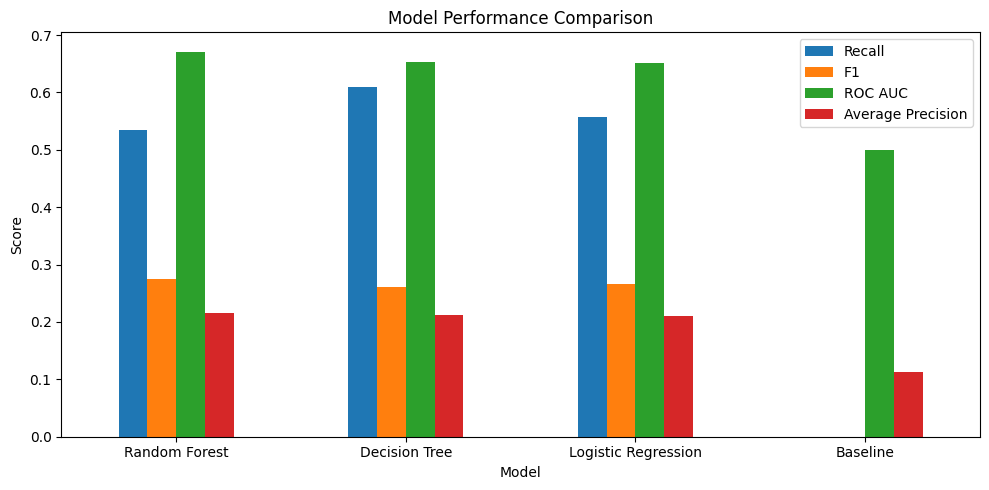

In [16]:
results_df[
    ["Recall", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Confusion Matrix

Inspect the confusion matrix for the best-performing model after comparing the evaluation metrics.


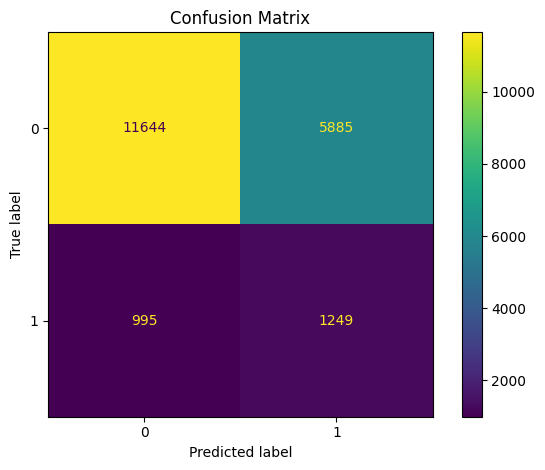

In [17]:
# Replace this with the model selected from the comparison table
final_model = logistic_model

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 16. ROC and Precision-Recall Curves


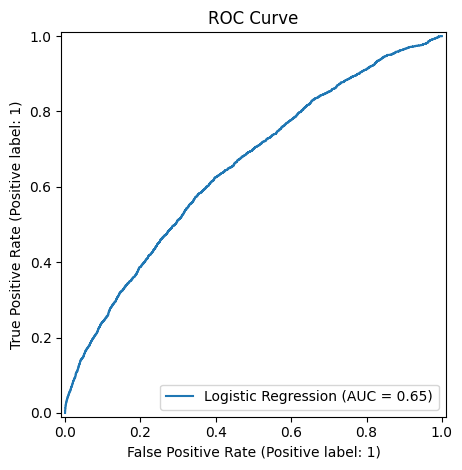

In [18]:
RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

plt.title("ROC Curve")
plt.tight_layout()
plt.show()


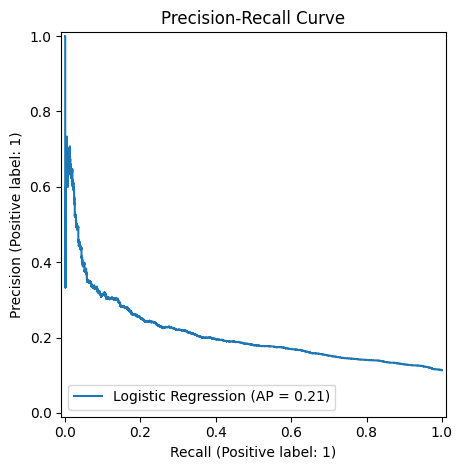

In [19]:
PrecisionRecallDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


## 17. Logistic Regression Feature Importance

Inspect the largest positive and negative logistic regression coefficients. Positive coefficients are associated with higher predicted probability of 30-day readmission, while negative coefficients are associated with lower predicted probability.


In [20]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

largest_positive = coefficient_df.nlargest(15, "coefficient")
largest_negative = coefficient_df.nsmallest(15, "coefficient")

print("Largest positive coefficients")
display(largest_positive)

print("Largest negative coefficients")
display(largest_negative)


Largest positive coefficients


,feature,coefficient
531,cat__diag_1_643,2.065545
796,cat__diag_2_136,1.964622
303,cat__diag_1_358,1.945050
1527,cat__diag_3_156,1.819156
225,cat__diag_1_271,1.764201
1905,cat__diag_3_602,1.748386
1097,cat__diag_2_500,1.710258
2015,cat__diag_3_755,1.664055
1319,cat__diag_2_826,1.641446
104,cat__diag_1_146,1.628939


Largest negative coefficients


,feature,coefficient
1853,cat__diag_3_537,-1.916371
1040,cat__diag_2_429,-1.813034
926,cat__diag_2_289,-1.778277
2090,cat__diag_3_873,-1.765308
258,cat__diag_1_304,-1.730280
776,cat__diag_1_V53,-1.711114
1304,cat__diag_2_807,-1.707123
52,cat__medical_specialty_Otolaryngology,-1.673199
961,cat__diag_2_327,-1.656788
172,cat__diag_1_235,-1.637581


## 18. Random Forest Feature Importance


In [21]:
forest_feature_names = (
    forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

forest_importances = (
    forest_model
    .named_steps["classifier"]
    .feature_importances_
)

forest_importance_df = (
    pd.DataFrame({
        "feature": forest_feature_names,
        "importance": forest_importances
    })
    .sort_values("importance", ascending=False)
)

forest_importance_df.head(20)


,feature,importance
9,num__number_inpatient,0.117155
11,num__prior_utilization,0.085748
1,num__discharge_disposition_id,0.063318
6,num__num_medications,0.034504
4,num__num_lab_procedures,0.031178
3,num__time_in_hospital,0.031013
10,num__number_diagnoses,0.026132
13,num__age_midpoint,0.024514
8,num__number_emergency,0.022644
5,num__num_procedures,0.014527


## 19. Model Performance Summary

The table below summarizes the evaluation metrics for each classification model.

In [22]:
summary_table = (
    results_df
    .loc[
        [
            "Baseline",
            "Logistic Regression",
            "Decision Tree",
            "Random Forest"
        ]
    ]
    .round(3)
)

display(summary_table)

,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Model,,,,,,
Baseline,0.887,0.000,0.000,0.000,0.500,0.113
Logistic Regression,0.652,0.175,0.557,0.266,0.651,0.210
Decision Tree,0.609,0.166,0.610,0.262,0.653,0.212
Random Forest,0.678,0.184,0.535,0.274,0.671,0.215


## 20. Conclusions

This project developed and evaluated several machine learning models to predict 30-day hospital readmission using the cleaned diabetes dataset. A group-based train/test split was used to ensure that encounters from the same patient did not appear in both the training and testing sets, reducing patient-level data leakage.

The baseline model achieved the highest accuracy but failed to identify any patients who were readmitted. Although its accuracy was **0.887**, both recall and F1-score were **0.000**, demonstrating that accuracy alone is not an appropriate evaluation metric for this imbalanced classification problem.

Among the predictive models, the Random Forest achieved the strongest overall performance. It produced the highest ROC AUC (**0.671**), highest F1-score (**0.274**), and highest Average Precision (**0.215**). The Decision Tree achieved the highest recall (**0.610**), identifying the largest proportion of patients who were readmitted within 30 days. Logistic Regression achieved a recall of **0.557** with a ROC AUC of **0.651**, providing competitive performance while remaining the most interpretable model.

Feature importance analysis showed that previous healthcare utilization was one of the strongest predictors of readmission. The most influential variables included `number_inpatient`, the engineered `prior_utilization` feature, `discharge_disposition_id`, `num_medications`, `num_lab_procedures`, `time_in_hospital`, `diagnosis_count`, and `age_midpoint`. These findings were consistent with patterns observed during the exploratory data analysis.

Although the Random Forest produced the strongest overall performance, the highest ROC AUC obtained (0.671) indicates only moderate predictive ability. This suggests that important factors affecting hospital readmission are not fully captured in the available dataset. Variables such as socioeconomic status, outpatient follow-up, medication adherence, and provider-level characteristics may improve predictive performance if available.

Future work could include additional feature engineering, hyperparameter tuning through cross-validation, more advanced ensemble methods such as XGBoost or LightGBM, and additional approaches for handling class imbalance.

Overall, this project established a complete predictive modeling pipeline, including data cleaning, exploratory data analysis, feature engineering, model development, evaluation, and interpretation. The Random Forest model achieved the strongest overall predictive performance, while previous healthcare utilization variables consistently emerged as the most important predictors of 30-day hospital readmission.

Although these models successfully identify variables that are associated with readmission, they do not establish whether these variables causally influence patient outcomes. Predictive models are designed to maximize forecasting accuracy rather than estimate treatment effects or causal relationships.

The next phase of this project will extend beyond prediction by applying causal inference methods to investigate potential causal factors associated with hospital readmission. Techniques such as propensity score methods, inverse probability weighting, matching, regression adjustment, or doubly robust estimation can be used to estimate treatment effects while accounting for observed confounding. This complementary analysis will help distinguish variables that are predictive of readmission from those that may have a causal impact on patient outcomes.